/tmp/ipykernel_9937/426012446.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("tab10", len(probs))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


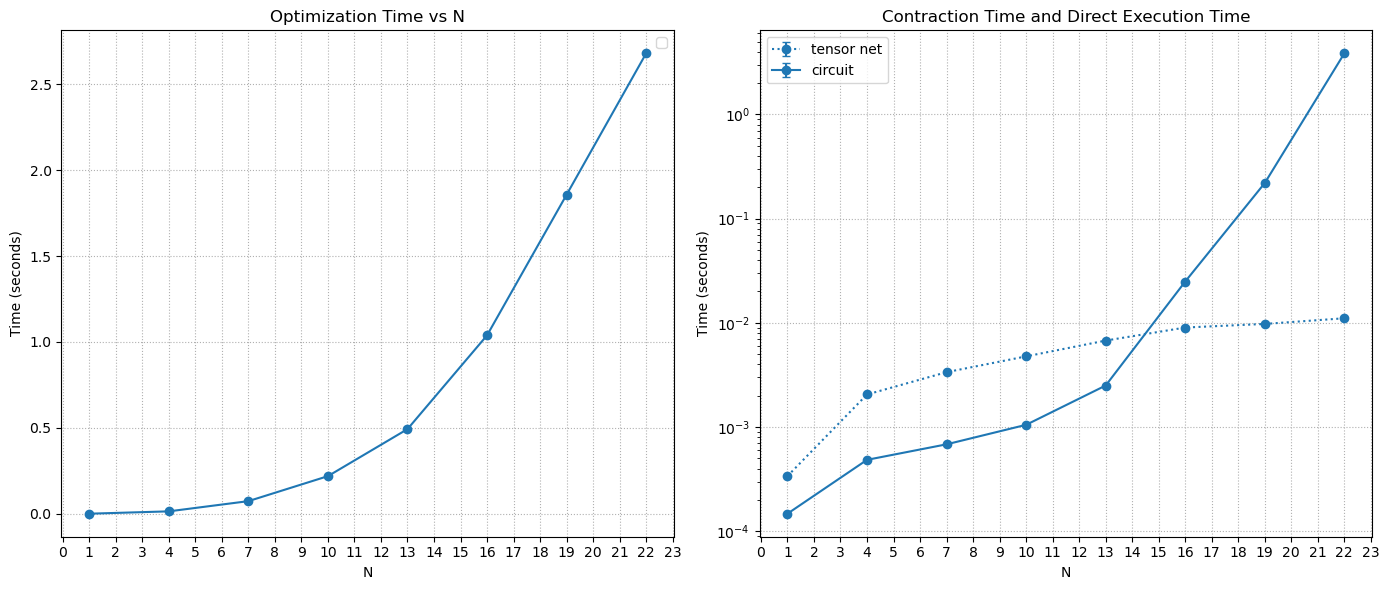

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator

df = pd.read_csv("optimization_and_contraction_times_nn.csv")

probs = sorted(df["probability"].unique())

colors = cm.get_cmap("tab10", len(probs))
color_map = {prob: colors(i) for i, prob in enumerate(probs)}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for prob in probs[:1]:
    group = df[df["probability"] == prob]
    color = color_map[prob]

    axes[0].errorbar(group["N"], group["opt_time_mean"], yerr=group["opt_time_std"],
                     #label=f"p={prob}"
                     color=color,
                     marker='o', capsize=3)

    ln1 = axes[1].errorbar(group["N"], group["conv_time_mean"], yerr=group["conv_time_std"],
                           label=f"tensor net", color=color, linestyle=':', marker='o',capsize=3)

    ln2 = axes[1].errorbar(group["N"], group["circuit_time_mean"], yerr=group["circuit_time_std"],
                           label=f"circuit", color=color, ls='-', marker='o',capsize=3)

axes[0].set_title("Optimization Time vs N")
axes[0].set_ylabel("Time (seconds)")
axes[0].legend()


handles, labels = axes[1].get_legend_handles_labels()

sorted_items = sorted(zip(labels, handles),
                      key=lambda x: ('circuit' in x[0], x[0]))
labels, handles = zip(*sorted_items)

axes[1].set_yscale("log")
axes[1].set_title("Contraction Time and Direct Execution Time")
axes[1].legend(handles, labels)

for ax in axes:
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, which='both', axis='x')
    ax.set_xlabel("N")
    ax.set_ylabel("Time (seconds)")
    ax.grid(ls=':')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9937/3678019156.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("tab10", len(N_values))


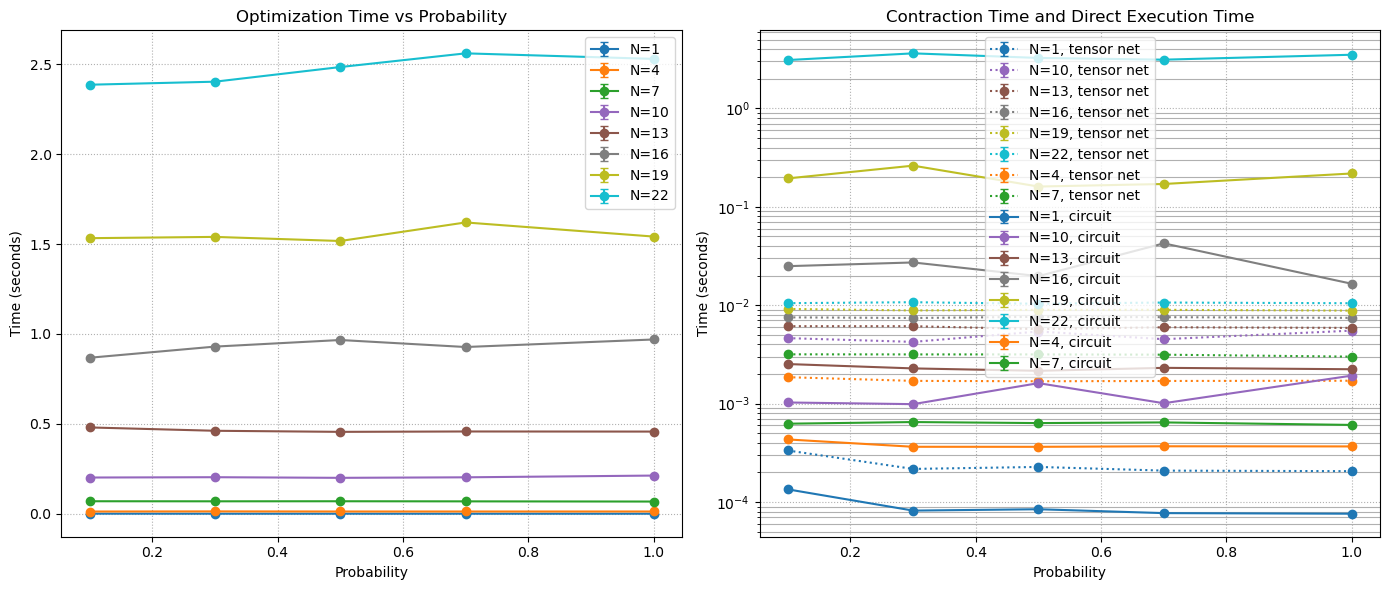

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_csv("optimization_and_contraction_times_nn.csv")

# Get unique N values and sort them
N_values = sorted(df["N"].unique())

# Create colormap for different N values
colors = cm.get_cmap("tab10", len(N_values))
color_map = {N: colors(i) for i, N in enumerate(N_values)}

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot optimization time vs probability
for N in N_values:
    group = df[df["N"] == N]
    color = color_map[N]
    
    axes[0].errorbar(group["probability"], group["opt_time_mean"], yerr=group["opt_time_std"],
                    label=f"N={N}", color=color,
                    marker='o', capsize=3)

# Plot contraction and circuit times vs probability
for N in N_values:
    group = df[df["N"] == N]
    color = color_map[N]
    
    ln1 = axes[1].errorbar(group["probability"], group["conv_time_mean"], yerr=group["conv_time_std"],
                          label=f"N={N}, tensor net", color=color, linestyle=':', marker='o', capsize=3)
    
    ln2 = axes[1].errorbar(group["probability"], group["circuit_time_mean"], yerr=group["circuit_time_std"],
                          label=f"N={N}, circuit", color=color, ls='-', marker='o', capsize=3)

# Set titles and labels
axes[0].set_title("Optimization Time vs Probability")
axes[0].set_ylabel("Time (seconds)")
axes[0].legend()

# Sort legend entries
handles, labels = axes[1].get_legend_handles_labels()
sorted_items = sorted(zip(labels, handles),
                     key=lambda x: ('circuit' in x[0], x[0]))
labels, handles = zip(*sorted_items)

axes[1].set_yscale("log")
axes[1].set_title("Contraction Time and Direct Execution Time")
axes[1].legend(handles, labels)

# Format axes
for ax in axes:
    ax.grid(True, which='both', axis='both')
    ax.set_xlabel("Probability")
    ax.set_ylabel("Time (seconds)")
    ax.grid(ls=':')

plt.tight_layout()
plt.show()